In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
# TFIDF Vectorizer for text data TF Means Term Frequency and IDF means Inverse Document Frequency
# Load the email spam dataset
df = pd.read_csv('spam.csv', encoding='latin-1', usecols=['v1', 'v2'])
df = df.rename(columns={'v1': 'label', 'v2': 'message'}) 

print("Dataset loaded successfully!")
print(df.head())

X_train, X_test, y_train, y_test = train_test_split(
    df["message"], df["label"], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Step 6: Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Step 7: Predictions
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

Dataset loaded successfully!
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [34]:
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9587


In [39]:


from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred, pos_label="spam") # Use "spam" string here
recall = recall_score(y_test, y_pred, pos_label="spam")
f1 = f1_score(y_test, y_pred, pos_label="spam")

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")



Precision: 0.9727
Recall: 0.7133
F1-Score: 0.8231


In [41]:
# 3. Split the email spam dataset into train/test sets and report the confusion matrix results.
# *

from sklearn.metrics import confusion_matrix
# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

print('Confusion Matrix:')
print(conf_matrix)


# print true positives, false positives, true negatives, and false negatives
tn, fp, fn, tp = conf_matrix.ravel()
print(f'True Positives Actually Spam: {tp}')
print(f'False Positives Actually Ham: {fp}')
print(f'True Negatives Actually Ham but Predicted Spam: {tn}')
print(f'False Negatives Actually Spam but Predicted Ham: {fn}')

Confusion Matrix:
[[962   3]
 [ 43 107]]
True Positives Actually Spam: 107
False Positives Actually Ham: 3
True Negatives Actually Ham but Predicted Spam: 962
False Negatives Actually Spam but Predicted Ham: 43


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
# Vectorize the text data using CountVectorizer this vetorizer will convert the text data into a matrix of token counts and it will be used to train the logistic regression model. it is different from tfidf vectorizer which will convert the text data into a matrix of tf-idf features. the count vectorizer will count the number of times each word appears in the text data and it will be used to train the logistic regression model. the tfidf vectorizer will calculate the term frequency-inverse document frequency for each word in the text data and it will be used to train the logistic regression model.

# the better way to vectorize the text data is to use the tfidf vectorizer because it will give more weight to the words that are more important in the text data and it will give less weight to the words that are less important in the text data. the count vectorizer will give equal weight to all the words in the text data and it will not be able to capture the importance of the words in the text data.


count_vectorizer = CountVectorizer()
X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

# Train the Logistic Regression model
model_count = LogisticRegression()
model_count.fit(X_train_count, y_train)

# Make predictions on the test set
y_pred_count = model_count.predict(X_test_count)

# Compute accuracy
accuracy_count = accuracy_score(y_test, y_pred_count)
precision_count = precision_score(y_test, y_pred_count, pos_label="spam")
recall_count = recall_score(y_test, y_pred_count, pos_label="spam")
f1_count = f1_score(y_test, y_pred_count, pos_label="spam")

print("Results with CountVectorizer:")
print(f'Accuracy with CountVectorizer: {accuracy_count:.4f}')
print(f'Precision with CountVectorizer: {precision_count:.4f}')
print(f'Recall with CountVectorizer: {recall_count:.4f}')
print(f'F1 Score with CountVectorizer: {f1_count:.4f}')



# Compare with TF-IDF results
print("Results with TF-IDF:")
print(f'Accuracy with TF-IDF: {accuracy:.4f}')
print(f'Precision with TF-IDF: {precision:.4f}')
print(f'Recall with TF-IDF: {recall:.4f}')
print(f'F1 Score with TF-IDF: {f1:.4f}')

Results with CountVectorizer:
Accuracy with CountVectorizer: 0.9776
Precision with CountVectorizer: 0.9921
Recall with CountVectorizer: 0.8400
F1 Score with CountVectorizer: 0.9097
Results with TF-IDF:
Accuracy with TF-IDF: 0.9587
Precision with TF-IDF: 0.9727
Recall with TF-IDF: 0.7133
F1 Score with TF-IDF: 0.8231


In [83]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

# Load Titanic dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Select features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features].copy()  # <- copy to avoid chained assignment warnings
y = df['Survived']

# Handle missing values (assign instead of inplace)
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Fare'] = X['Fare'].fillna(X['Fare'].median())
X['Embarked'] = X['Embarked'].fillna(X['Embarked'].mode()[0])

# Encode categorical features
le_sex = LabelEncoder()
X['Sex'] = le_sex.fit_transform(X['Sex'])

le_embarked = LabelEncoder()
X['Embarked'] = le_embarked.fit_transform(X['Embarked'].astype(str))


# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and compute accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [105]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


# print confusion matrix
from sklearn.metrics import confusion_matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)
n, fp, fn, tp = conf_matrix.ravel()
print(f'True Positives: {tp}')
print(f'False Positives: {fp}')
print(f'True Negatives: {n}')
print(f'False Negatives: {fn}')

Precision: 0.7563
Recall: 0.8738
F1-Score: 0.8108
Confusion Matrix:
[[73 29]
 [13 90]]
True Positives: 90
False Positives: 29
True Negatives: 73
False Negatives: 13


In [ ]:
# Compare Logistic Regression accuracy on the Titanic dataset before and after handling missing values.

# first we will delete the missing rows and then we will handle the missing values and compare the accuracy

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load Titanic dataset
df = pd.read_csv("Titanic-Dataset.csv")
# Select features and target
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features].copy()  
y = df['Survived']

# remove the rows with missing values
X_dropped = X.dropna()
y_dropped = y[X_dropped.index]


# Encode categorical features
le_sex = LabelEncoder()
X_dropped['Sex'] = le_sex.fit_transform(X_dropped['Sex'])
le_embarked = LabelEncoder()
X_dropped['Embarked'] = le_embarked.fit_transform(X_dropped['Embarked'].astype(str))
# Split the dataset
X_train_dropped, X_test_dropped, y_train_dropped, y_test_dropped = train_test_split(
    X_dropped, y_dropped, test_size=0.2, random_state=42)

# Train Logistic Regression
model_dropped = LogisticRegression(max_iter=1000)
model_dropped.fit(X_train_dropped, y_train_dropped)
# Predict and compute accuracy
y_pred_dropped = model_dropped.predict(X_test_dropped)
accuracy_dropped = accuracy_score(y_test_dropped, y_pred_dropped)
print(f"Accuracy after dropping missing values: {accuracy_dropped:.4f}")


Accuracy after dropping missing values: 0.7972


In [88]:
# 9. On the Iris dataset, map sepal/petal features to targets using Logistic Regression and compute accuracy.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
# Load Iris dataset
df = pd.read_csv("iris.csv")

# Select features and target
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[features]
y = df['Species']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# Predict and compute accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on Iris dataset: {accuracy:.4f}")

Accuracy on Iris dataset: 1.0000


In [89]:
# precision, recall, and F1-score for the Iris dataset
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


In [ ]:
# Train Logistic Regression on the Iris dataset with only two feature columns and report the accuracy.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
# Load Iris dataset
df = pd.read_csv("iris.csv")
# Select only two features and target
features = ['SepalLengthCm', 'SepalWidthCm']  # Only two features
X = df[features]
y = df['Species']
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# Predict and compute accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with only two features: {accuracy:.4f}")


Accuracy with only two features: 0.9000


Accuracy with only two features: 0.9000


c:\Users\alikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Text(0, 0.5, 'Sepal Width')

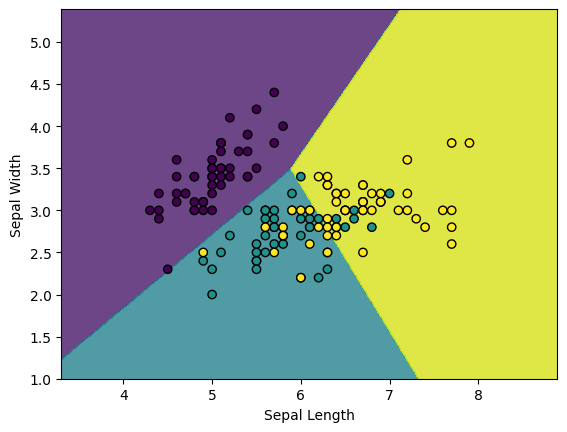

In [98]:
# Visualize decision boundaries of Logistic Regression for two classes of the Iris dataset and calculate accuracy. 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Load Iris dataset
df = pd.read_csv("iris.csv")
# Select features and target
features = ['SepalLengthCm', 'SepalWidthCm']
X = df[features]
y = df['Species']
# y is categorical, we need to encode it to numeric
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)
# Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
# Predict and compute accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with only two features: {accuracy:.4f}")

# Visualize decision boundaries


# we are creating a grid of points that will be used to plot the decision boundaries. we are using the minimum and maximum values of the SepalLengthCm feature to define the range of the grid. we are adding and subtracting 1 to create a margin around the data points.
x_min, x_max = X['SepalLengthCm'].min() - 1, X['SepalLengthCm'].max() + 1 

# we are doing the same for the SepalWidthCm feature to define the range of the grid in the y-axis.
y_min, y_max = X['SepalWidthCm'].min() - 1, X['SepalWidthCm'].max() + 1

# we are creating a meshgrid of points using the np.meshgrid function. we are using np.arange to create a range of values from x_min to x_max with a step of 0.01 for the x-axis and from y_min to y_max with a step of 0.01 for the y-axis. this will create a grid of points that we can use to plot the decision boundaries.
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# we are using the predict method of the trained logistic regression model to predict the class labels for each point in the grid. we are using np.c_ to concatenate the xx and yy arrays into a single array of shape (n_samples, 2) where n_samples is the number of points in the grid. we are then reshaping the predicted labels Z to match the shape of the grid so that we can plot it using contourf.
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])


Z = Z.reshape(xx.shape)
# we are using plt.contourf to plot the decision boundaries. we are passing the xx and yy grid and the predicted labels Z to contourf. we are also setting alpha=0.8 to make the colors of the decision boundaries slightly transparent. we are then using plt.scatter to plot the original data points on top of the decision boundaries. we are coloring the data points based on their true class labels (y_encoded) and adding edge colors and
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X['SepalLengthCm'], X['SepalWidthCm'], c=y_encoded, edgecolors='k', marker='o')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')

In [99]:
#  On the Heart Disease dataset, train Logistic Regression and compute accuracy.

df = pd.read_csv("heart.csv")
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X = df[features]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)   
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on Heart Disease dataset: {accuracy:.4f}")

Accuracy on Heart Disease dataset: 0.7951


In [100]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Precision: 0.7563
Recall: 0.8738
F1-Score: 0.8108


Accuracy on Heart Disease dataset: 0.7951
Precision: 0.7563
Recall: 0.8738
F1-Score: 0.8108
Confusion Matrix:
[[73 29]
 [13 90]]
True Positives Actually Heart Disease: 90
False Positives Actually Healthy: 29
True Negatives Actually Healthy: 73
False Negatives Actually Heart Disease but Predicted Healthy: 13


Text(45.72222222222221, 0.5, 'Actual')

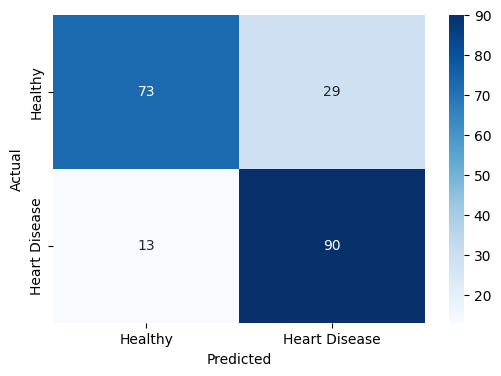

In [104]:
#  On the Heart Disease dataset, train Logistic Regression and compute accuracy.

df = pd.read_csv("heart.csv")
features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X = df[features]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)   
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy on Heart Disease dataset: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


#plot the confusion matrix for the Heart Disease dataset


conf_matrix = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(conf_matrix)
tn, fp, fn, tp = conf_matrix.ravel()
print(f'True Positives Actually Heart Disease: {tp}')
print(f'False Positives Actually Healthy: {fp}')
print(f'True Negatives Actually Healthy: {tn}')
print(f'False Negatives Actually Heart Disease but Predicted Healthy: {fn}')

# plot the conusion matrix using seaborn heatmap
import seaborn as sns
plt.figure(figsize=(6,4))   
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Heart Disease'], yticklabels=['Healthy', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
